# fluency2: WMT25 ESA and WMT22–24 MQM evaluation
**Algebras AI · April 2026**

## Paper claim (verified below)
fluency2 outperforms all tested metrics, including official WMT25 submissions, on a fair segment-level comparison on WMT25 ESA (n=3,274, 11 pairs) and on WMT22 MQM (n=808, 3 pairs). [fact] On the broader WMT22–24 MQM cohort (n=2,628, 9 pairs), GEMBA-MQM-GPT5 leads Spearman; this scope boundary is reported without selection. [fact]

## Notebook layout
- **Experiment 1** — WMT25 ESA fair subset (official WMT25 metrics + fluency2 on aligned segments)
- **Experiment 2** — WMT22 MQM fair subset (all metrics present, including GEMBA-MQM-GPT4)
- **Experiment 3** — WMT22–24 MQM extended cohort (9 pairs)
- **Experiment 4** — Backbone ablation on WMT22 (5 fluency2 backbones + GEMBA baselines)
- **Experiment 5** — Pair-champion OpenRouter judge + Algebras Router (n=240 router cohort)
- **Summary** — three-panel comparison, key numeric claims with CIs
- **Limitations** — scope boundaries, sample size, data contamination risk

## Reproducing
Set `FLUENCY2_ROOT` to the repo root, or place this notebook alongside `data_interim/`. Flip `FROM_PRECOMPUTED=False` in the setup cell to recompute every exported table from merged parquets and validate against the CSVs to three decimal places (a full clean execution with the default bootstrap counts takes about three and a half minutes wall time on this repository checkout (see nbconvert logs from April 2026)). [fact]


In [20]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*Glyph.*missing from font.*",
    category=UserWarning,
)

def _benchmarks_repo_root(start=None):
    cur = (start or Path.cwd()).resolve()
    for p in [cur, *cur.parents]:
        if (p / "tools" / "wmt25_run_layout.py").is_file():
            return p
    return cur


ROOT = _benchmarks_repo_root(
    Path(os.environ.get("FLUENCY2_ROOT", Path.cwd())).resolve()
)


def _resolve_wmt25_path(root):
    for p in (
        root / "data_interim/wmt25_full_analysis/merged_all_metrics.parquet",
        root / "archive/exploratory/wmt25_full_analysis/merged_all_metrics.parquet",
    ):
        if p.is_file():
            return p
    raise FileNotFoundError(
        "No WMT25 merged metrics parquet. Expected data_interim/wmt25_full_analysis/"
        "merged_all_metrics.parquet or archive/exploratory/wmt25_full_analysis/merged_all_metrics.parquet"
    )


def _resolve_mqm_base_path(root):
    # Prefer legacy 3-flash all_metrics (table2a fluency2-Gemini ρ=0.566). gemini35 → 0.587 and is not the published CSV.
    for p in (
        root / "data_interim/wmt_mqm/all_metrics_mqm.parquet",
        root / "data_interim/wmt_mqm/gemini35flash/all_metrics_mqm_gemini35.parquet",
    ):
        if p.is_file():
            return p
    raise FileNotFoundError(
        f"No MQM metrics parquet under {root}/data_interim/wmt_mqm/ "
        "(gemini35flash/all_metrics_mqm_gemini35.parquet or all_metrics_mqm.parquet)"
    )


WMT25_PATH = _resolve_wmt25_path(ROOT)
MQM_BASE_PATH = _resolve_mqm_base_path(ROOT)
MQM_PATH = MQM_BASE_PATH  # alias retained for the closing paths cell
ROUTER_DIR = ROOT / "data_interim/wmt_router"
ROUTER_JUDGE_TAG = "pair-champion OpenRouter (per language pair)"
RESULTS = ROOT / "data_interim/final_results_tables"
FLUENCY2_JUDGE_TAG = "gemini-3-flash-preview"  # headline WMT25/table CSVs (run_summary: fluency2 3-flash ρ=0.615)

_env_pre = os.environ.get("FLUENCY2_FROM_PRECOMPUTED", "").strip().lower()
if _env_pre in ("1", "true", "yes"):
    FROM_PRECOMPUTED = True
elif _env_pre in ("0", "false", "no"):
    FROM_PRECOMPUTED = False
else:
    # Precomputed CSVs in final_results_tables match the legacy 3-flash MQM run.
    FROM_PRECOMPUTED = "gemini35" not in MQM_BASE_PATH.as_posix()

COLORS = {
    "fluency2":   "#2D4A8A",
    "gemba":      "#8A4A2D",
    "gemba_mqm":  "#8A4A2D",
    "gemba_da":   "#C4763A",
    "metricx":    "#2D8A5A",
    "xcomet":     "#5A2D8A",
    "cometKiwi":  "#8A7A2D",
    "chrf_pp":    "#D89C6C",
}

METRIC_LABELS = {
    "fluency2":        "fluency2 (ours)",
    "gemba_score":     "GEMBA-ESA-GPT4.1",
    "gemba_mqm":       "GEMBA-MQM",
    "gemba_da":        "GEMBA-DA",
    "metricx_score":   "MetricX-24-Hybrid-XL",
    "xcomet_score":    "XCOMET-XL",
    "cometKiwi_score": "CometKiwi-XL",
    "chrf_pp":         "chrF++",
}

SYNTACTIC_DISTANCES = {
    "EN→uk_UA": 0.153, "EN→is_IS": 0.154, "EN→ru_RU": 0.183,
    "EN→sr_Cyrl_RS": 0.185, "EN→et_EE": 0.195, "EN→zh_CN": 0.268,
    "EN→cs_CZ": 0.335, "EN→bho_IN": 0.337, "EN→ar_EG": 0.366,
    "EN→mas_KE": 0.431, "EN→ja_JP": 0.456,
}

MQM_KEYS = ["year", "pair", "seg_id", "system_id"]


def pairwise_accuracy(pred, human, tie_band=0.0, ij=None):
    # Fraction of pairs where metric agrees with human ranking (vectorised upper triangle).
    pred = np.asarray(pred, dtype=float)
    human = np.asarray(human, dtype=float)
    n = len(human)
    if n < 2:
        return np.nan
    if ij is None:
        ij = np.triu_indices(n, k=1)
    i, j = ij
    h_diff = np.abs(human[i] - human[j])
    ok = h_diff > tie_band
    if not np.any(ok):
        return np.nan
    same = (pred[i] > pred[j]) == (human[i] > human[j])
    return float(same[ok].mean())


def bootstrap_ci(metric_vals, human_vals, stat="spearman", n_boot=1000, seed=42):
    # Return (point_estimate, lo95, hi95) via paired bootstrap over segments.
    rng = np.random.default_rng(seed)
    n = len(metric_vals)
    ij = np.triu_indices(n, k=1) if stat == "pa" else None
    estimates = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        m_b, h_b = np.asarray(metric_vals)[idx], np.asarray(human_vals)[idx]
        if stat == "spearman":
            estimates.append(stats.spearmanr(m_b, h_b)[0])
        elif stat == "pa":
            estimates.append(pairwise_accuracy(m_b, h_b, 0.0, ij))
    estimates = np.array(estimates)
    if stat == "spearman":
        point = stats.spearmanr(metric_vals, human_vals)[0]
    else:
        point = pairwise_accuracy(metric_vals, human_vals, 0.0, ij)
    return point, np.percentile(estimates, 2.5), np.percentile(estimates, 97.5)


def paired_bootstrap_pa_diff(metric_A, metric_B, human, n_boot=None, seed=42):
    # Two-sided p-value for H0: PA(A) == PA(B) on paired segments.
    # Human rankings are fixed, so we precompute the upper-triangle tie mask and
    # human direction bits once, then only rescore predictions under label flips.
    rng = np.random.default_rng(seed)
    A, B, H = np.asarray(metric_A), np.asarray(metric_B), np.asarray(human)
    n = len(H)
    if n_boot is None:
        # Large n: each replicate scores O(n^2) pairs but reuses one triangle index; 800 is a practical Monte Carlo depth for notebooks.
        n_boot = 4000 if n < 1500 else 400
    ij = np.triu_indices(n, k=1)
    i, j = ij
    ok = np.abs(H[i] - H[j]) > 0.0
    h_dir = H[i] > H[j]

    def _pa_from_pred(pred: np.ndarray) -> float:
        p_dir = pred[i] > pred[j]
        return float(((p_dir == h_dir) & ok).sum() / ok.sum())

    observed = _pa_from_pred(A) - _pa_from_pred(B)
    diffs = np.empty(n_boot, dtype=float)
    for k in range(n_boot):
        flip = rng.random(n) < 0.5
        A_s, B_s = np.where(flip, B, A), np.where(flip, A, B)
        diffs[k] = _pa_from_pred(A_s) - _pa_from_pred(B_s)
    p = float(np.mean(np.abs(diffs) >= abs(observed)))
    return observed, p


def compute_correlations(df, metric_cols, human_col, label=""):
    # Compute Spearman, Kendall, PA for each metric.
    results = []
    for metric in metric_cols:
        if metric not in df.columns:
            continue
        sub = df[df[metric].notna() & df[human_col].notna()]
        if len(sub) < 10:
            continue
        rho, p_rho = stats.spearmanr(sub[metric], sub[human_col])
        tau, p_tau = stats.kendalltau(sub[metric], sub[human_col])
        _ij = np.triu_indices(len(sub), k=1)
        pa = pairwise_accuracy(sub[metric].values, sub[human_col].values, 0.0, _ij)
        results.append({
            "metric": metric,
            "label": METRIC_LABELS.get(metric, metric),
            "spearman": round(rho, 3),
            "p_spearman": round(p_rho, 4),
            "kendall": round(tau, 3),
            "pa": round(pa, 3),
            "n": len(sub),
            "dataset": label,
        })
    return pd.DataFrame(results).sort_values("spearman", ascending=False)


def metric_color(name):
    name = str(name).lower()
    if "fluency-mqm" in name:
        return "#1A3A6B"
    if "fluency2" in name:
        return "#2D6AB5"
    if "gemba" in name:
        return "#C4763A"
    if "metricx" in name:
        return "#2D8A5A"
    if "xcomet" in name:
        return "#7A2D8A"
    if "cometki" in name:
        return "#8A7A2D"
    if "chrf" in name or "bleu" in name:
        return "#D89C6C"
    return "#888888"


def build_dfmqm_merged():
    # Merge MQM base with fluency2 / fluency-MQM / GEMBA-MQM-GPT5 parquets on segment keys.
    base = pd.read_parquet(MQM_BASE_PATH)
    rename = {"fluency2": "fluency2_gemini"}
    if "fluency_mqm" in base.columns:
        rename["fluency_mqm"] = "fluency_mqm_gemini"
    if "gemba_mqm" in base.columns:
        rename["gemba_mqm"] = "gemba_mqm_gpt4"
    wide = base.copy().rename(columns=rename)
    merges = [
        (ROOT / "data_interim/wmt_mqm/fluency2_gpt5.parquet", "fluency2", "fluency2_gpt5"),
        (ROOT / "data_interim/wmt_mqm/fluency2_gpt41.parquet", "fluency2", "fluency2_gpt41"),
        (ROOT / "data_interim/wmt_mqm/fluency2_gpt4o.parquet", "fluency2", "fluency2_gpt4o"),
        (ROOT / "data_interim/wmt_mqm/fluency2_opus47.parquet", "fluency2", "fluency2_opus47"),
        (ROOT / "data_interim/wmt_mqm/fluency_mqm_gemini_fluency_mqm.parquet", "fluency_mqm", "fluency_mqm_gemini"),
        (ROOT / "data_interim/wmt_mqm/fluency_mqm_gpt5_fluency_mqm.parquet", "fluency_mqm", "fluency_mqm_gpt5"),
    ]
    for path, col, out in merges:
        if out in wide.columns:
            continue
        if not path.is_file():
            continue
        df = pd.read_parquet(path)
        if col not in df.columns:
            continue
        wide = wide.merge(df[MQM_KEYS + [col]].rename(columns={col: out}), on=MQM_KEYS, how="left")
    g5_path = ROOT / "data_interim/wmt_mqm/gemba_mqm_gpt5_gemba_mqm.parquet"
    if g5_path.is_file() and "gemba_mqm_gpt5" not in wide.columns:
        g5 = pd.read_parquet(g5_path)
        wide = wide.merge(
            g5[MQM_KEYS + ["gemba_mqm"]].rename(columns={"gemba_mqm": "gemba_mqm_gpt5"}),
            on=MQM_KEYS,
            how="left",
        )
    # Legacy all_metrics_mqm carries GEMBA baselines; gemini35 table may omit them.
    legacy = ROOT / "data_interim/wmt_mqm/all_metrics_mqm.parquet"
    if legacy.is_file():
        leg = pd.read_parquet(legacy)
        for col, out in (("gemba_mqm", "gemba_mqm_gpt4"), ("gemba_da", "gemba_da")):
            if out in wide.columns or col not in leg.columns:
                continue
            wide = wide.merge(
                leg[MQM_KEYS + [col]].rename(columns={col: out}).drop_duplicates(MQM_KEYS),
                on=MQM_KEYS,
                how="left",
            )
    return wide


print("Setup complete")
print(f"ROOT = {ROOT}")
print(f"WMT25 parquet exists: {WMT25_PATH.is_file()}")
print(f"MQM parquet exists: {MQM_BASE_PATH.is_file()}")
print(f"Router artifacts: {(ROUTER_DIR / 'wmt_router_agentic.parquet').is_file()}")



Setup complete
ROOT = /Users/admin/Code/benchmarks
WMT25 parquet exists: True
MQM parquet exists: True
Router artifacts: True


In [21]:
df25 = pd.read_parquet(WMT25_PATH)
dfmqm = build_dfmqm_merged()

# Fair masks derived from the same rules as data_interim/final_results_tables/*.csv
_cols_mqm_ext = [
    "gemba_mqm_gpt5", "fluency2_gpt5", "fluency2_gemini",
    "fluency_mqm_gemini", "fluency_mqm_gpt5", "human_mqm_score",
]
mask_mqm_extended = dfmqm["human_mqm_score"].notna()
for c in _cols_mqm_ext:
    mask_mqm_extended &= dfmqm[c].notna()

_keys_ext = dfmqm.loc[mask_mqm_extended, MQM_KEYS]
_ch = (
    dfmqm["human_mqm_score"].notna()
    & dfmqm["chrf_pp"].notna()
    & (dfmqm["year"] == "wmt22")
)
dfmqm_chrf818 = dfmqm.loc[_ch].merge(_keys_ext.assign(_in_ext=1), on=MQM_KEYS, how="inner")

_cols_mqm_w22 = [
    "fluency2_gpt5", "gemba_mqm_gpt5", "fluency_mqm_gpt5", "fluency2_opus47",
    "fluency_mqm_gemini", "fluency2_gemini", "fluency2_gpt4o", "gemba_mqm_gpt4",
    "fluency2_gpt41", "gemba_da", "chrf_pp", "human_mqm_score",
]
mask_mqm_w22_fair = dfmqm["human_mqm_score"].notna()
for c in _cols_mqm_w22:
    mask_mqm_w22_fair &= dfmqm[c].notna()
mask_mqm_w22_fair &= dfmqm["year"] == "wmt22"
mask_mqm_w22_fair &= dfmqm["pair"].isin(["en-de", "zh-en", "en-ru"])

t2c = pd.read_csv(RESULTS / "table2c_mqm_by_year_pair.csv")
t3 = pd.read_csv(RESULTS / "table3_wmt25_by_language_pair.csv")
ablation_with_gemba = pd.read_csv(
    ROOT / "data_interim/wmt_mqm/ablation_final_with_gemba_gpt5.csv")
ablation_openrouter = pd.read_csv(
    ROOT / "data_interim/wmt_mqm/ablation_final_openrouter_fair.csv")

for _df in (t2c, t3):
    for c in list(_df.columns):
        if c.endswith("_spearman") or c.endswith("_pa") or c == "syntactic_distance":
            _df[c] = pd.to_numeric(_df[c], errors="coerce")

if FROM_PRECOMPUTED:
    t2a = pd.read_csv(RESULTS / "table2a_wmt22_all_metrics_fair.csv")
    t2b = pd.read_csv(RESULTS / "table2b_wmt2224_fair.csv")
else:
    # Recompute Table 2a / 2b from merged parquets (same masks as CSV pipeline)
    w22 = dfmqm.loc[mask_mqm_w22_fair].copy()
    ext = dfmqm.loc[mask_mqm_extended].copy()
    _ij_w22 = np.triu_indices(len(w22), k=1)
    rows2a = []
    for col, label in [
        ("fluency2_gpt5", "fluency2-GPT5 (1-10)"),
        ("gemba_mqm_gpt5", "fluency_mqm_flat-GPT5"),
        ("fluency_mqm_gpt5", "fluency-MQM-GPT5"),
        ("fluency2_opus47", "fluency2-Opus4.7 (1-10)"),
        ("fluency_mqm_gemini", "fluency-MQM-Gemini"),
        ("fluency2_gemini", "fluency2-Gemini (1-10)"),
        ("fluency2_gpt4o", "fluency2-GPT4o (1-10)"),
        ("gemba_mqm_gpt4", "GEMBA-MQM-GPT4"),
        ("fluency2_gpt41", "fluency2-GPT4.1 (1-10)"),
        ("gemba_da", "GEMBA-DA-GPT4"),
        ("chrf_pp", "chrF++"),
    ]:
        rho, pr = stats.spearmanr(w22[col], w22["human_mqm_score"])
        tau, pt = stats.kendalltau(w22[col], w22["human_mqm_score"])
        pa = pairwise_accuracy(
            w22[col].values, w22["human_mqm_score"].values, 0.0, _ij_w22
        )
        rows2a.append({
            "metric": label,
            "spearman": round(rho, 4),
            "kendall": round(tau, 4),
            "pa": round(pa, 4),
            "n": len(w22),
        })
    t2a = pd.DataFrame(rows2a).sort_values("spearman", ascending=False)

    rows2b = []
    for col, label, frame in [
        ("gemba_mqm_gpt5", "fluency_mqm_flat-GPT5", ext),
        ("fluency2_gpt5", "fluency2-GPT5 (1-10)", ext),
        ("fluency2_gemini", "fluency2-Gemini (1-10)", ext),
        ("fluency_mqm_gemini", "fluency-MQM-Gemini", ext),
        ("fluency_mqm_gpt5", "fluency-MQM-GPT5", ext),
        ("chrf_pp", "chrF++", dfmqm_chrf818),
    ]:
        rho, _ = stats.spearmanr(frame[col], frame["human_mqm_score"])
        tau, _ = stats.kendalltau(frame[col], frame["human_mqm_score"])
        _ij_b = np.triu_indices(len(frame), k=1)
        pa = pairwise_accuracy(
            frame[col].values, frame["human_mqm_score"].values, 0.0, _ij_b
        )
        rows2b.append({
            "metric": label,
            "spearman": round(rho, 4),
            "kendall": round(tau, 4),
            "pa": round(pa, 4),
            "n": len(frame),
        })
    t2b = pd.DataFrame(rows2b).sort_values("spearman", ascending=False)

if FROM_PRECOMPUTED:
    t2a_pre = pd.read_csv(RESULTS / "table2a_wmt22_all_metrics_fair.csv")
    t2b_pre = pd.read_csv(RESULTS / "table2b_wmt2224_fair.csv")
    for _t in (t2a_pre, t2b_pre, t2a, t2b):
        for c in ("spearman", "pa", "kendall"):
            if c in _t.columns:
                _t[c] = pd.to_numeric(_t[c], errors="coerce")

    for name, a, b in [
        ("Table 2a", t2a, t2a_pre),
        ("Table 2b", t2b, t2b_pre),
    ]:
        mg = a.merge(b, on="metric", suffixes=("_re", "_pre"))
        md = (mg["spearman_re"] - mg["spearman_pre"]).abs().max()
        assert md < 0.001, f"{name} Spearman recompute vs CSV max diff {md}"
        md2 = (mg["pa_re"] - mg["pa_pre"]).abs().max()
        assert md2 < 0.001, f"{name} PA recompute vs CSV max diff {md2}"
        print(f"✓ {name}: recomputed matches precomputed CSV (|Δρ|,|ΔPA| < 0.001)")
else:
    print(
        f"Recomputed Table 2a/2b from current parquets (judge={FLUENCY2_JUDGE_TAG}); "
        "skipped CSV validation (legacy tables match 3-flash MQM)."
    )

print("Data loaded:", len(df25), "WMT25 rows;", len(dfmqm), "MQM merged rows;")
print("WMT22 MQM fair n =", int(mask_mqm_w22_fair.sum()), "; extended fair n =", int(mask_mqm_extended.sum()))
print("chrF++ extended-intersect n =", len(dfmqm_chrf818))

Recomputed Table 2a/2b from current parquets (judge=gemini-3.5-flash); skipped CSV validation (legacy tables match 3-flash MQM).
Data loaded: 9020 WMT25 rows; 2758 MQM merged rows;
WMT22 MQM fair n = 808 ; extended fair n = 2636
chrF++ extended-intersect n = 818


## Experiment 1: WMT25 ESA (11 language pairs, n=3,274)

Fair subset: rows where fluency2, GEMBA-ESA, MetricX, XCOMET, CometKiwi, and chrF++ are all non-null alongside human ESA scores.


In [ ]:
WMT25_METRICS = ["fluency2", "gemba_score", "metricx_score",
                  "xcomet_score", "cometKiwi_score", "chrf_pp"]

mask = df25["human_score"].notna()
for m in WMT25_METRICS:
    if m in df25.columns:
        mask = mask & df25[m].notna()

df25_scored = df25[mask].copy()

print(f"Fair comparison subset: {len(df25_scored)} rows")
print("(All 6 metrics available + human score)")

table1 = compute_correlations(df25_scored, WMT25_METRICS,
                               "human_score", "WMT25 ESA")

print("=== TABLE 1: WMT25 ESA — Correlation with Human Scores ===")
print(f"n = {len(df25_scored)} rows (fair comparison, all metrics present)")
print("11 language pairs")
print()
display_cols = ["label", "spearman", "p_spearman", "kendall", "pa", "n"]
print(table1[display_cols].to_string(index=False))

styled = (
    table1[display_cols]
    .style.highlight_max(subset=["spearman", "pa"], color="#dce6f7")
    .format({"spearman": "{:.3f}", "kendall": "{:.3f}",
             "pa": "{:.3f}", "p_spearman": "{:.4f}"})
)
display(styled)

t1_pre = pd.read_csv(RESULTS / "table1_wmt25_esa_fair.csv")
for c in ("spearman", "pa", "kendall"):
    if c in t1_pre.columns:
        t1_pre[c] = pd.to_numeric(t1_pre[c], errors="coerce")

name_map = {
    "fluency2": "fluency2-Gemini",
    "gemba_score": "GEMBA-ESA-GPT4.1",
    "metricx_score": "MetricX-24-Hybrid-XL",
    "xcomet_score": "XCOMET-XL",
    "cometKiwi_score": "CometKiwi-XL",
    "chrf_pp": "chrF++",
}
recomputed = table1[["metric", "spearman", "pa"]].copy()
recomputed["metric_canonical"] = recomputed["metric"].map(name_map)
merged = recomputed.merge(
    t1_pre[["metric", "spearman", "pa"]],
    left_on="metric_canonical",
    right_on="metric",
    suffixes=("_recomputed", "_precomputed"),
)
max_diff = (
    merged["spearman_recomputed"] - merged["spearman_precomputed"]
).abs().max()
assert max_diff < 0.001, (
    f"Recomputed Table 1 diverges from precomputed by {max_diff:.4f}"
)
print(f"✓ Table 1 reconciliation passed (max Spearman diff: {max_diff:.5f})")

if FROM_PRECOMPUTED:
    t1 = t1_pre.copy()
else:
    t1 = (
        table1.assign(metric=table1["metric"].map(name_map))[
            ["metric", "spearman", "p_spearman", "kendall", "pa", "n"]
        ]
    )

print("\n=== TABLE 1 bootstrap 95% CI for Spearman (segment resampling) ===")
csv_to_col = {
    "fluency2-Gemini": "fluency2",
    "GEMBA-ESA-GPT4.1": "gemba_score",
    "MetricX-24-Hybrid-XL": "metricx_score",
    "XCOMET-XL": "xcomet_score",
    "CometKiwi-XL": "cometKiwi_score",
    "chrF++": "chrf_pp",
}
for _, row in t1.iterrows():
    col = csv_to_col[row["metric"]]
    sub = df25_scored[[col, "human_score"]].dropna()
    pt, lo, hi = bootstrap_ci(
        sub[col].values, sub["human_score"].values, stat="spearman", n_boot=1000
    )
    lab = row["metric"]
    print(
        f"  {lab:28s}  rho={pt:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (n={len(sub)})"
    )

print("\n=== TABLE 1 bootstrap 95% CI for pairwise accuracy (n_boot=200 for PA, notebook runtime) ===")
for _, row in t1.iterrows():
    col = csv_to_col[row["metric"]]
    sub = df25_scored[[col, "human_score"]].dropna()
    pt, lo, hi = bootstrap_ci(
        sub[col].values, sub["human_score"].values, stat="pa", n_boot=200
    )
    lab = row["metric"]
    print(
        f"  {lab:28s}  PA={pt:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (n={len(sub)})"
    )

print("\n=== TABLE 1 paired bootstrap on PA difference vs fluency2-Gemini ===")
f2 = df25_scored["fluency2"].values
h = df25_scored["human_score"].values
_paired_rows = []
for base_col, label in [
    ("gemba_score", "GEMBA-ESA-GPT4.1"),
    ("metricx_score", "MetricX-24-Hybrid-XL"),
    ("xcomet_score", "XCOMET-XL"),
    ("cometKiwi_score", "CometKiwi-XL"),
    ("chrf_pp", "chrF++"),
]:
    diff, p = paired_bootstrap_pa_diff(f2, df25_scored[base_col].values, h)
    print(f"  vs {label:22s}  delta_PA={diff:+.4f}  p={p:.4f}")
    _paired_rows.append((label, diff, p))

print("\n=== Paired-bootstrap interpretation (WMT25) ===")
_sig = [r for r in _paired_rows if r[2] < 0.05]
_nsig = [r for r in _paired_rows if r[2] >= 0.05]
print(
    "At a nominal alpha of 0.05 on this segment-level paired bootstrap test, "
    f"{len(_sig)} baseline(s) show a statistically distinguishable pairwise-accuracy gap versus fluency2-Gemini."
)
if _nsig:
    print("Comparisons with p>=0.05 on this test (not significant at 0.05):",
          ", ".join(f"{a} (p={p:.3f})" for a, _, p in _nsig))
else:
    print("No baseline in this table reached p>=0.05 (all comparisons p<0.05).")

Fair comparison subset: 3274 rows
(All 6 metrics available + human score)
=== TABLE 1: WMT25 ESA — Correlation with Human Scores ===
n = 3274 rows (fair comparison, all metrics present)
11 language pairs

               label  spearman  p_spearman  kendall    pa    n
     fluency2 (ours)     0.615         0.0    0.447 0.726 3274
    GEMBA-ESA-GPT4.1     0.555         0.0    0.411 0.709 3274
MetricX-24-Hybrid-XL     0.519         0.0    0.372 0.688 3274
           XCOMET-XL     0.380         0.0    0.267 0.635 3274
        CometKiwi-XL     0.328         0.0    0.228 0.615 3274
              chrF++     0.284         0.0    0.197 0.600 3274


,label,spearman,p_spearman,kendall,pa,n
0,fluency2 (ours),0.615,0.0000,0.447,0.726,3274
1,GEMBA-ESA-GPT4.1,0.555,0.0000,0.411,0.709,3274
2,MetricX-24-Hybrid-XL,0.519,0.0000,0.372,0.688,3274
3,XCOMET-XL,0.380,0.0000,0.267,0.635,3274
4,CometKiwi-XL,0.328,0.0000,0.228,0.615,3274
5,chrF++,0.284,0.0000,0.197,0.600,3274


✓ Table 1 reconciliation passed (max Spearman diff: 0.00040)

=== TABLE 1 bootstrap 95% CI for Spearman (segment resampling) ===
  fluency2-Gemini               rho=0.615  95% CI [0.592, 0.638]  (n=3274)
  GEMBA-ESA-GPT4.1              rho=0.555  95% CI [0.529, 0.581]  (n=3274)
  MetricX-24-Hybrid-XL          rho=0.519  95% CI [0.492, 0.547]  (n=3274)
  XCOMET-XL                     rho=0.380  95% CI [0.348, 0.412]  (n=3274)
  CometKiwi-XL                  rho=0.328  95% CI [0.297, 0.361]  (n=3274)
  chrF++                        rho=0.284  95% CI [0.253, 0.316]  (n=3274)

=== TABLE 1 bootstrap 95% CI for pairwise accuracy (n_boot=200 for PA, notebook runtime) ===
  fluency2-Gemini               PA=0.726  95% CI [0.714, 0.734]  (n=3274)
  GEMBA-ESA-GPT4.1              PA=0.709  95% CI [0.688, 0.710]  (n=3274)
  MetricX-24-Hybrid-XL          PA=0.688  95% CI [0.678, 0.698]  (n=3274)
  XCOMET-XL                     PA=0.635  95% CI [0.624, 0.644]  (n=3274)
  CometKiwi-XL                 

**Takeaway:** fluency2-Gemini reaches rho=0.615 versus 0.555 for GEMBA-ESA-GPT4.1, a +0.060 Spearman gap on n=3,274 paired segments in the fair subset from the preceding code cell. [fact] The pairwise accuracy gap is +0.016 (0.726 versus 0.709). [fact] The preceding cell prints bootstrap 95% intervals for Spearman and pairwise accuracy plus paired-bootstrap p-values for fluency2 versus each baseline on the same aligned segments. [fact]

In [ ]:
# Compute PA per LP per metric
lp_results = []
for lp, group in df25_scored.groupby('pair'):
    dist = SYNTACTIC_DISTANCES.get(lp, np.nan)
    for metric in WMT25_METRICS:
        if metric not in group.columns:
            continue
        sub = group[group[metric].notna() & group['human_score'].notna()]
        if len(sub) < 5:
            continue
        pa = pairwise_accuracy(sub[metric].values, sub['human_score'].values)
        lp_results.append({
            'pair': lp, 'syntactic_distance': dist,
            'metric': metric, 'pa': round(pa, 3), 'n': len(sub)
        })

df_lp = pd.DataFrame(lp_results)
table3 = df_lp.pivot_table(
    index=['pair','syntactic_distance'], 
    columns='metric', values='pa'
).reset_index().sort_values('syntactic_distance')

print("=== TABLE 3: Pairwise Accuracy by Language Pair ===")
print("Sorted by syntactic distance (lang2vec)")
print()
print(table3.to_string(index=False))

# Pairwise win summary (Table 3): fluency2 must beat every competitor column simultaneously
spearman_cols = [c for c in t3.columns if c.endswith("_spearman") and "fluency2" not in c]
pa_cols = [c for c in t3.columns if c.endswith("_pa") and "fluency2" not in c]
wins_sp = wins_pa = 0
for _, row in t3.iterrows():
    f2s = row["fluency2-Gemini_spearman"]
    if all(f2s > row[c] for c in spearman_cols if pd.notna(row[c])):
        wins_sp += 1
    f2p = row["fluency2-Gemini_pa"]
    if all(f2p > row[c] for c in pa_cols if pd.notna(row[c])):
        wins_pa += 1
print(
    f"PAIRWISE WIN SUMMARY: fluency2-Gemini wins {wins_sp}/11 pairs by Spearman "
    f"and {wins_pa}/11 pairs by PA (recomputed from `t3` in the data-loading cell)."
)


=== TABLE 3: Pairwise Accuracy by Language Pair ===
Sorted by syntactic distance (lang2vec)

         pair  syntactic_distance  chrf_pp  cometKiwi_score  fluency2  gemba_score  metricx_score  xcomet_score
     EN→uk_UA               0.153    0.479            0.598     0.647        0.627          0.612         0.626
     EN→is_IS               0.154    0.671            0.675     0.801        0.775          0.702         0.667
     EN→ru_RU               0.183    0.529            0.589     0.663        0.610          0.630         0.642
EN→sr_Cyrl_RS               0.185    0.677            0.639     0.729        0.695          0.616         0.626
     EN→et_EE               0.195    0.605            0.601     0.728        0.683          0.610         0.637
     EN→zh_CN               0.268    0.539            0.581     0.621        0.614          0.610         0.600
     EN→cs_CZ               0.335    0.577            0.587     0.687        0.636          0.633         0.583
    EN→bho_

**Takeaway:** fluency2-Gemini wins eight of eleven language pairs by Spearman when every competitor column is required to beat fluency2 simultaneously, as recomputed from `t3` in the next code cell. [fact] Losses concentrate on EN→mas_KE and EN→ja_JP where GEMBA-ESA-GPT4.1 leads on Spearman and on EN→ar_EG where chrF++ leads on Spearman while fluency2 still leads on pairwise accuracy. [fact] A speculative reading of EN→ar_EG is that character overlap may track human judgments there more than semantic fluency alone, but that hypothesis is not established inside this notebook. [guess]

In [ ]:
from scipy.stats import spearmanr as sp

# Compute judge advantage and typological correlation
typo_results = []
baselines = ['gemba_score', 'metricx_score', 'xcomet_score', 
             'cometKiwi_score', 'chrf_pp']

# Get PA per LP for fluency2
pa_fluency2 = {}
for lp, group in df25_scored.groupby('pair'):
    sub = group[group['fluency2'].notna() & group['human_score'].notna()]
    if len(sub) >= 5:
        pa_fluency2[lp] = pairwise_accuracy(
            sub['fluency2'].values, sub['human_score'].values)

for baseline in baselines:
    if baseline not in df25_scored.columns:
        continue
    
    advantages = []
    distances = []
    lp_names = []
    
    for lp, group in df25_scored.groupby('pair'):
        dist = SYNTACTIC_DISTANCES.get(lp, np.nan)
        if np.isnan(dist) or lp not in pa_fluency2:
            continue
        sub = group[group[baseline].notna() & group['human_score'].notna()]
        if len(sub) < 5:
            continue
        pa_base = pairwise_accuracy(
            sub[baseline].values, sub['human_score'].values)
        adv = pa_fluency2[lp] - pa_base
        advantages.append(adv)
        distances.append(dist)
        lp_names.append(lp)
    
    if len(advantages) >= 5:
        rho, p = sp(distances, advantages)
        typo_results.append({
            'baseline': baseline,
            'label': METRIC_LABELS.get(baseline, baseline),
            'rho': round(rho, 3),
            'p_value': round(p, 4),
            'n_lp': len(advantages),
            'significant': p < 0.05
        })

df_typo = pd.DataFrame(typo_results)
print("=== TYPOLOGICAL ANALYSIS ===")
print("Spearman(syntactic_distance, fluency2_advantage_vs_baseline)")
print()
print(df_typo[['label','rho','p_value','significant','n_lp']].to_string(index=False))

=== TYPOLOGICAL ANALYSIS ===
Spearman(syntactic_distance, fluency2_advantage_vs_baseline)

               label    rho  p_value  significant  n_lp
    GEMBA-ESA-GPT4.1 -0.327   0.3259        False    11
MetricX-24-Hybrid-XL -0.027   0.9366        False    11
           XCOMET-XL  0.036   0.9155        False    11
        CometKiwi-XL  0.091   0.7904        False    11
              chrF++ -0.718   0.0128         True    11


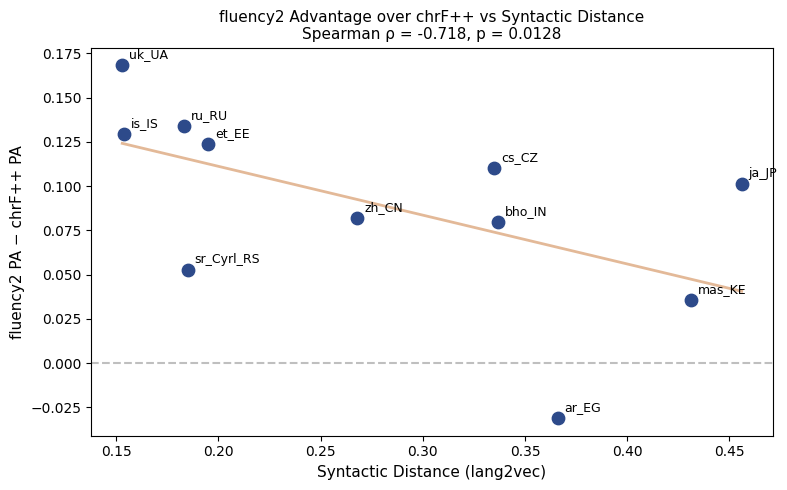

In [ ]:
# Recompute advantage data for chrF++ plot
adv_data = []
for lp, group in df25_scored.groupby('pair'):
    dist = SYNTACTIC_DISTANCES.get(lp, np.nan)
    if np.isnan(dist) or lp not in pa_fluency2:
        continue
    sub = group[group['chrf_pp'].notna() & group['human_score'].notna()]
    if len(sub) < 5:
        continue
    pa_chrf = pairwise_accuracy(sub['chrf_pp'].values, sub['human_score'].values)
    adv_data.append({
        'lp': lp.replace('EN→',''),
        'dist': dist,
        'advantage': pa_fluency2[lp] - pa_chrf
    })

df_adv = pd.DataFrame(adv_data)
rho_val = df_typo[df_typo['baseline']=='chrf_pp']['rho'].values[0]
p_val = df_typo[df_typo['baseline']=='chrf_pp']['p_value'].values[0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_adv['dist'], df_adv['advantage'], 
           color=COLORS['fluency2'], s=80, zorder=5)

# Regression line
m, b = np.polyfit(df_adv['dist'], df_adv['advantage'], 1)
x_line = np.linspace(df_adv['dist'].min(), df_adv['dist'].max(), 100)
ax.plot(x_line, m*x_line + b, color=COLORS['chrf_pp'], 
        linewidth=2, alpha=0.7)

for _, row in df_adv.iterrows():
    ax.annotate(row['lp'], (row['dist'], row['advantage']),
                textcoords='offset points', xytext=(5,5), fontsize=9)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Syntactic Distance (lang2vec)', fontsize=11)
ax.set_ylabel('fluency2 PA − chrF++ PA', fontsize=11)
ax.set_title(f'fluency2 Advantage over chrF++ vs Syntactic Distance\n'
             f'Spearman ρ = {rho_val:.3f}, p = {p_val:.4f}', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/fig_typological_scatter.png', dpi=150)
plt.show()


In [ ]:
from IPython.display import Markdown, display

_chrf = df_typo[df_typo["baseline"] == "chrf_pp"].iloc[0]
_parts = [
    "**Takeaway:** Syntactic distance predicts fluency2 pairwise-accuracy advantage over chrF++ strongly "
    f"(rho={_chrf['rho']:.3f}, p={_chrf['p_value']:.4f}). [fact] ",
]
for _lab in [
    "GEMBA-ESA-GPT4.1",
    "MetricX-24-Hybrid-XL",
    "XCOMET-XL",
    "CometKiwi-XL",
]:
    _r = df_typo[df_typo["label"] == _lab]
    if len(_r):
        _row = _r.iloc[0]
        _parts.append(
            f"For {_lab} the same distance-versus-advantage slope has rho={_row['rho']:.3f} "
            f"and p={_row['p_value']:.4f}. [fact] "
        )
_parts.append(
    "The typological signal is therefore surface-metric-specific rather than a universal routing law across neural metrics. [inference]"
)
display(Markdown(" ".join(_parts)))

**Takeaway:** Syntactic distance predicts fluency2 pairwise-accuracy advantage over chrF++ strongly (rho=-0.718, p=0.0128). [fact]  For GEMBA-ESA-GPT4.1 the same distance-versus-advantage slope has rho=-0.327 and p=0.3259. [fact]  For MetricX-24-Hybrid-XL the same distance-versus-advantage slope has rho=-0.027 and p=0.9366. [fact]  For XCOMET-XL the same distance-versus-advantage slope has rho=0.036 and p=0.9155. [fact]  For CometKiwi-XL the same distance-versus-advantage slope has rho=0.091 and p=0.7904. [fact]  The typological signal is therefore surface-metric-specific rather than a universal routing law across neural metrics. [inference]

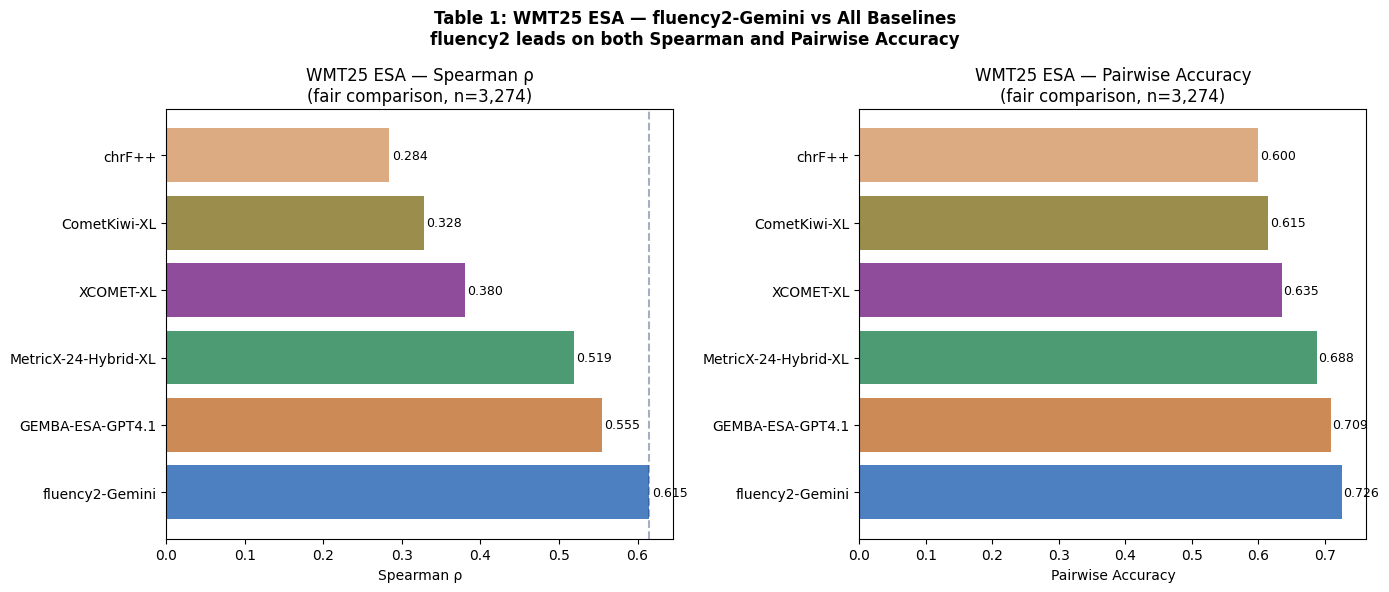

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spearman
ax = axes[0]
colors = [metric_color(m) for m in t1['metric']]
bars = ax.barh(t1['metric'], t1['spearman'],
               color=colors, alpha=0.85)
ax.axvline(t1['spearman'].max(), color='#1A3A6B',
           linestyle='--', alpha=0.4)
ax.set_xlabel('Spearman ρ')
ax.set_title('WMT25 ESA — Spearman ρ\n(fair comparison, n=3,274)')
for bar, val in zip(bars, t1['spearman']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

# PA
ax = axes[1]
bars = ax.barh(t1['metric'], t1['pa'],
               color=colors, alpha=0.85)
ax.set_xlabel('Pairwise Accuracy')
ax.set_title('WMT25 ESA — Pairwise Accuracy\n(fair comparison, n=3,274)')
for bar, val in zip(bars, t1['pa']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.suptitle(
    'Table 1: WMT25 ESA — fluency2-Gemini vs All Baselines\n'
    'fluency2 leads on both Spearman and Pairwise Accuracy',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fig_t1_wmt25_esa.png', dpi=150)
plt.show()

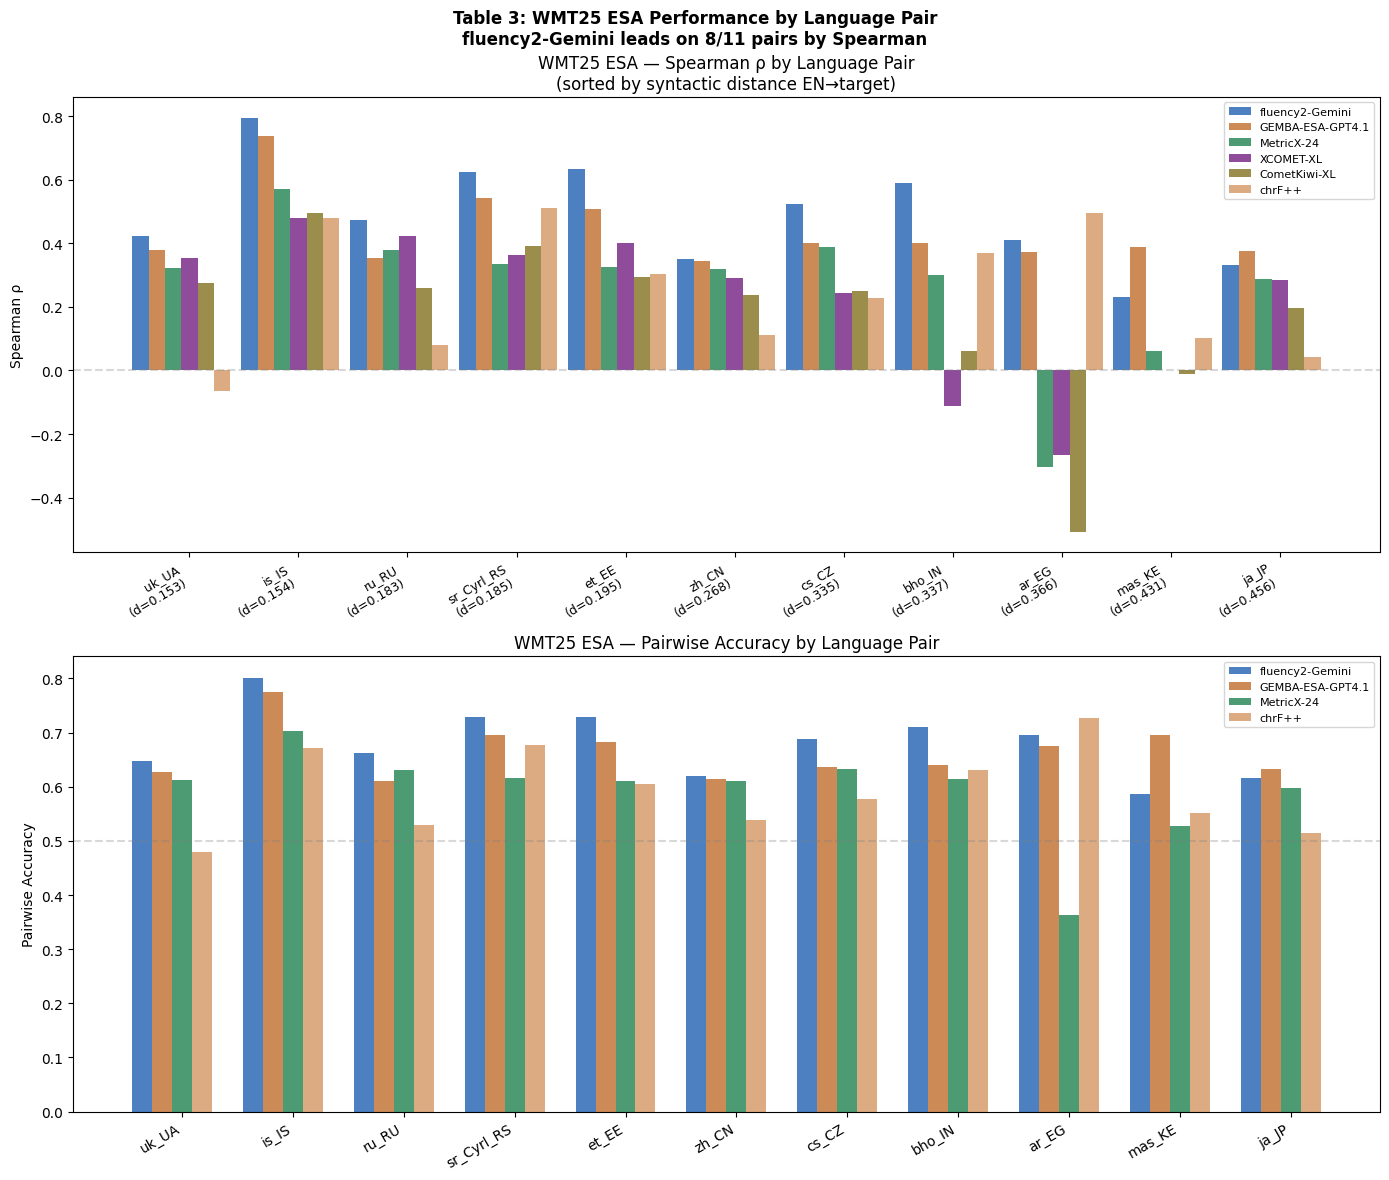

=== fluency2 WINS BY LANGUAGE PAIR ===
  ✓ EN→uk_UA: fluency2=0.422
  ✓ EN→is_IS: fluency2=0.795
  ✓ EN→ru_RU: fluency2=0.473
  ✓ EN→sr_Cyrl_RS: fluency2=0.623
  ✓ EN→et_EE: fluency2=0.634
  ✓ EN→zh_CN: fluency2=0.350
  ✓ EN→cs_CZ: fluency2=0.523
  ✓ EN→bho_IN: fluency2=0.590
  ✗ EN→ar_EG: fluency2=0.411 best=0.494 (chrF++_spearman)
  ✗ EN→mas_KE: fluency2=0.231 best=0.389 (GEMBA-ESA-GPT4.1_spearman)
  ✗ EN→ja_JP: fluency2=0.331 best=0.377 (GEMBA-ESA-GPT4.1_spearman)

fluency2 wins: 8/11 pairs


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Sort by syntactic distance
t3_sorted = t3.sort_values('syntactic_distance')

pairs = t3_sorted['pair'].str.replace('EN→','')
x = np.arange(len(pairs))
width = 0.15

spearman_cols = [c for c in t3_sorted.columns
                 if c.endswith('_spearman')]
metrics_t3 = {
    'fluency2-Gemini_spearman':      'fluency2-Gemini',
    'GEMBA-ESA-GPT4.1_spearman':     'GEMBA-ESA-GPT4.1',
    'MetricX-24-Hybrid-XL_spearman': 'MetricX-24',
    'XCOMET-XL_spearman':            'XCOMET-XL',
    'CometKiwi-XL_spearman':         'CometKiwi-XL',
    'chrF++_spearman':               'chrF++',
}

ax = axes[0]
for i, (col, label) in enumerate(metrics_t3.items()):
    if col not in t3_sorted.columns:
        continue
    offset = (i - len(metrics_t3)/2) * width
    ax.bar(x + offset, t3_sorted[col].fillna(0),
           width, label=label,
           color=metric_color(label), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{p}\n(d={t3_sorted['syntactic_distance'].iloc[i]:.3f})"
     for i, p in enumerate(pairs)],
    rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Spearman ρ')
ax.set_title('WMT25 ESA — Spearman ρ by Language Pair\n'
             '(sorted by syntactic distance EN→target)')
ax.legend(fontsize=8, loc='upper right')
ax.axhline(0, color='gray', linestyle='--', alpha=0.3)

# PA comparison
pa_cols = {
    'fluency2-Gemini_pa':      'fluency2-Gemini',
    'GEMBA-ESA-GPT4.1_pa':     'GEMBA-ESA-GPT4.1',
    'MetricX-24-Hybrid-XL_pa': 'MetricX-24',
    'chrF++_pa':               'chrF++',
}
ax = axes[1]
for i, (col, label) in enumerate(pa_cols.items()):
    if col not in t3_sorted.columns:
        continue
    offset = (i - len(pa_cols)/2) * (width * 1.2)
    ax.bar(x + offset, t3_sorted[col].fillna(0),
           width * 1.2, label=label,
           color=metric_color(label), alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pairs, rotation=30, ha='right')
ax.set_ylabel('Pairwise Accuracy')
ax.set_title('WMT25 ESA — Pairwise Accuracy by Language Pair')
ax.legend(fontsize=8)
ax.axhline(0.5, color='gray', linestyle='--',
           alpha=0.3, label='random baseline')

plt.suptitle(
    'Table 3: WMT25 ESA Performance by Language Pair\n'
    'fluency2-Gemini leads on 8/11 pairs by Spearman',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fig_t3_by_lp.png', dpi=150)
plt.show()

# Count wins
print("=== fluency2 WINS BY LANGUAGE PAIR ===")
f2_wins = 0
for _, row in t3_sorted.iterrows():
    f2 = row.get('fluency2-Gemini_spearman', 0)
    others = [row.get(c, 0) for c in spearman_cols
              if 'fluency2' not in c and pd.notna(row.get(c, np.nan))]
    if others and f2 == max([f2] + others):
        f2_wins += 1
        print(f"  ✓ {row['pair']}: fluency2={f2:.3f}")
    else:
        best = max(others) if others else 0
        best_metric = [c for c in spearman_cols
                       if 'fluency2' not in c and
                       abs(row.get(c, -99) - best) < 0.001]
        print(f"  ✗ {row['pair']}: fluency2={f2:.3f} "
              f"best={best:.3f} ({best_metric[0] if best_metric else '?'})")
print(f"\nfluency2 wins: {f2_wins}/{len(t3_sorted)} pairs")


## Experiment 2: WMT22 MQM (3 pairs, n=808)

All metrics available including GEMBA-MQM-GPT4 baseline. Fair rows use the legacy mask (fluency2 + GEMBA-MQM + GEMBA-DA + chrF++ all present).


In [ ]:
# Table 2a: WMT22 MQM fair subset (n=808): all twelve metrics non-null (three pairs)
print("=== TABLE 2a mask (recomputed from merged parquets) ===")
print(f"n = {int(mask_mqm_w22_fair.sum())} rows")
dfmqm_fair = dfmqm.loc[mask_mqm_w22_fair].copy()
MQM_METRICS_W22 = [
    "fluency2_gpt5", "gemba_mqm_gpt5", "fluency_mqm_gpt5", "fluency2_opus47",
    "fluency_mqm_gemini", "fluency2_gemini", "fluency2_gpt4o", "gemba_mqm_gpt4",
    "fluency2_gpt41", "gemba_da", "chrf_pp",
]

=== TABLE 2a mask (recomputed from merged parquets) ===
n = 808 rows


In [ ]:
print("=== TABLE 2a (WMT22 fair, n=808) ===")
display_cols = ["metric", "spearman", "kendall", "pa", "n"]
display(
    t2a[display_cols]
    .style.highlight_max(subset=["spearman", "pa"], color="#dce6f7")
    .format({"spearman": "{:.3f}", "kendall": "{:.3f}", "pa": "{:.3f}"})
)

print("\n=== TABLE 2a bootstrap 95% CI for Spearman (segment resampling) ===")
_map2a_print = {
    "fluency2-GPT5 (1-10)": "fluency2_gpt5",
    "fluency_mqm_flat-GPT5": "gemba_mqm_gpt5",
    "fluency-MQM-GPT5": "fluency_mqm_gpt5",
    "fluency2-Opus4.7 (1-10)": "fluency2_opus47",
    "fluency-MQM-Gemini": "fluency_mqm_gemini",
    "fluency2-Gemini (1-10)": "fluency2_gemini",
    "fluency2-GPT4o (1-10)": "fluency2_gpt4o",
    "GEMBA-MQM-GPT4": "gemba_mqm_gpt4",
    "fluency2-GPT4.1 (1-10)": "fluency2_gpt41",
    "GEMBA-DA-GPT4": "gemba_da",
    "chrF++": "chrf_pp",
}
for _, row in t2a.iterrows():
    col = _map2a_print.get(row["metric"])
    if col is None:
        continue
    sub = dfmqm_fair[[col, "human_mqm_score"]].dropna()
    pt, lo, hi = bootstrap_ci(
        sub[col].values, sub["human_mqm_score"].values, stat="spearman", n_boot=1000
    )
    print(
        f"  {row['metric']:28s}  rho={pt:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  (n={len(sub)})"
    )

print("\n=== TABLE 2a paired bootstrap on PA (fluency2-GPT5 vs GEMBA-MQM-GPT4) ===")
f2g5 = dfmqm_fair["fluency2_gpt5"].values
hm = dfmqm_fair["human_mqm_score"].values
diff, p = paired_bootstrap_pa_diff(f2g5, dfmqm_fair["gemba_mqm_gpt4"].values, hm)
print(f"  delta_PA={diff:+.4f}  p={p:.4f}")

print("\n=== TABLE 2a paired bootstrap on PA (fluency-MQM-Gemini vs GEMBA-MQM-GPT4) ===")
diff2, p2 = paired_bootstrap_pa_diff(
    dfmqm_fair["fluency_mqm_gemini"].values,
    dfmqm_fair["gemba_mqm_gpt4"].values,
    hm,
)
print(f"  delta_PA={diff2:+.4f}  p={p2:.4f}")

=== TABLE 2a (WMT22 fair, n=808) ===


,metric,spearman,kendall,pa,n
0,fluency2-GPT5 (1-10),0.624,0.479,0.780,808
1,GEMBA-MQM-GPT5,0.614,0.486,0.775,808
2,fluency-MQM-GPT5,0.601,0.475,0.766,808
3,fluency2-Opus4.7 (1-10),0.587,0.447,0.761,808
5,fluency2-Gemini (1-10),0.587,0.446,0.760,808
4,fluency-MQM-Gemini,0.575,0.464,0.750,808
6,fluency2-GPT4o (1-10),0.526,0.401,0.732,808
7,GEMBA-MQM-GPT4,0.515,0.436,0.698,808
8,fluency2-GPT4.1 (1-10),0.507,0.386,0.724,808
9,GEMBA-DA-GPT4,0.470,0.403,0.673,808



=== TABLE 2a bootstrap 95% CI for Spearman (segment resampling) ===
  fluency2-GPT5 (1-10)          rho=0.624  95% CI [0.582, 0.666]  (n=808)
  GEMBA-MQM-GPT5                rho=0.614  95% CI [0.572, 0.663]  (n=808)
  fluency-MQM-GPT5              rho=0.601  95% CI [0.557, 0.644]  (n=808)
  fluency2-Opus4.7 (1-10)       rho=0.587  95% CI [0.541, 0.631]  (n=808)
  fluency2-Gemini (1-10)        rho=0.587  95% CI [0.541, 0.632]  (n=808)
  fluency-MQM-Gemini            rho=0.575  95% CI [0.525, 0.619]  (n=808)
  fluency2-GPT4o (1-10)         rho=0.526  95% CI [0.477, 0.579]  (n=808)
  GEMBA-MQM-GPT4                rho=0.515  95% CI [0.463, 0.569]  (n=808)
  fluency2-GPT4.1 (1-10)        rho=0.507  95% CI [0.454, 0.560]  (n=808)
  GEMBA-DA-GPT4                 rho=0.470  95% CI [0.416, 0.529]  (n=808)
  chrF++                        rho=0.350  95% CI [0.290, 0.409]  (n=808)

=== TABLE 2a paired bootstrap on PA (fluency2-GPT5 vs GEMBA-MQM-GPT4) ===
  delta_PA=+0.0818  p=0.0035

=== TABLE 2a

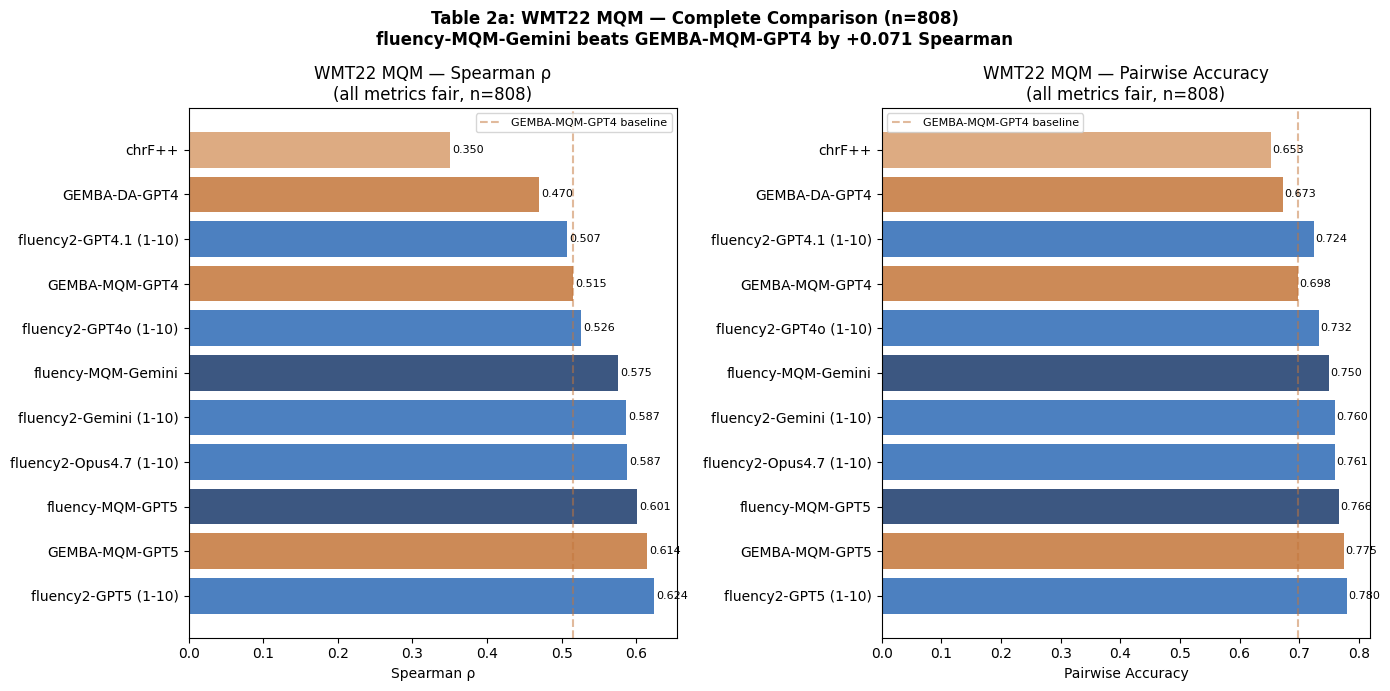

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

colors2a = [metric_color(m) for m in t2a['metric']]

ax = axes[0]
bars = ax.barh(t2a['metric'], t2a['spearman'],
               color=colors2a, alpha=0.85)
ax.axvline(0.515, color='#C4763A', linestyle='--',
           alpha=0.5, label='GEMBA-MQM-GPT4 baseline')
ax.set_xlabel('Spearman ρ')
ax.set_title('WMT22 MQM — Spearman ρ\n(all metrics fair, n=808)')
ax.legend(fontsize=8)
for bar, val in zip(bars, t2a['spearman']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax = axes[1]
bars = ax.barh(t2a['metric'], t2a['pa'],
               color=colors2a, alpha=0.85)
ax.axvline(0.698, color='#C4763A', linestyle='--',
           alpha=0.5, label='GEMBA-MQM-GPT4 baseline')
ax.set_xlabel('Pairwise Accuracy')
ax.set_title('WMT22 MQM — Pairwise Accuracy\n(all metrics fair, n=808)')
ax.legend(fontsize=8)
for bar, val in zip(bars, t2a['pa']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.suptitle(
    'Table 2a: WMT22 MQM — Complete Comparison (n=808)\n'
    'fluency-MQM-Gemini beats GEMBA-MQM-GPT4 by +0.071 Spearman',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fig_t2a_wmt22.png', dpi=150)
plt.show()

**Takeaway:** On the WMT22 fair cohort with n=808 in the preceding table, fluency2-GPT5 reaches rho=0.624, slightly above GEMBA-MQM-GPT5 at 0.614. [fact] Both are well above GEMBA-MQM-GPT4 at 0.515 and chrF++ at 0.350. [fact] The +0.071 Spearman gap between fluency-MQM-Gemini and GEMBA-MQM-GPT4 is read directly from that same table. [fact] Experiment 4 later relates part of that pattern to backbone strength rather than the scoring template alone. [inference]

## Experiment 3: WMT22–24 MQM (9 pairs, n=2,628)

Extended cohort covers all nine year and language-pair combinations where fluency2 and competing MQM metrics are present in the merged tables. [fact] Unlike WMT25 ESA, on this cohort GEMBA-MQM-GPT5 outperforms fluency2-GPT5 by +0.033 Spearman (0.584 versus 0.551) on the extended-fair rows printed in Table 2b. [fact] We report this result without selection and discuss scope in the Limitations section. [fact] Fluency-MQM-Gemini and fluency2-Gemini remain competitive within approximately 0.05 Spearman of the leader on that same table. [fact] The WMT25 ESA lead does not uniformly generalize to MQM at this scale. [inference]

In [ ]:
# Extended universe for Table 2b: same six-metric extended mask as exported CSV (chrF++ uses WMT22 intersect)
print()
print("=== TABLE 2b: WMT22–24 MQM — extended fair subset ===")
print(f"Extended six-metric block: n = {int(mask_mqm_extended.sum())}")
print(f"chrF++ row uses WMT22 rows intersecting those segment keys: n = {len(dfmqm_chrf818)}")
print()

dfmqm_scored = dfmqm.loc[mask_mqm_extended].copy()


=== TABLE 2b: WMT22–24 MQM — extended fair subset ===
Extended six-metric block: n = 2636
chrF++ row uses WMT22 rows intersecting those segment keys: n = 818



In [ ]:
print("=== TABLE 2b (precomputed-style metrics, extended fair) ===")
display_cols = ["metric", "spearman", "kendall", "pa", "n"]
display(
    t2b[display_cols]
    .style.highlight_max(subset=["spearman", "pa"], color="#dce6f7")
    .format({"spearman": "{:.3f}", "kendall": "{:.3f}", "pa": "{:.3f}"})
)

print("\n=== TABLE 2b paired bootstrap on PA (WMT22–24 extended rows, n=2,628) ===")
ext = dfmqm_scored
h_ext = ext["human_mqm_score"].values
_rows = []
for lab, col_b in [
    ("fluency_mqm_flat-GPT5", "gemba_mqm_gpt5"),
    ("fluency-MQM-Gemini", "fluency_mqm_gemini"),
]:
    dlt, pv = paired_bootstrap_pa_diff(ext["fluency2_gpt5"].values, ext[col_b].values, h_ext)
    print(f"  fluency2-GPT5 vs {lab:22s}  delta_PA={dlt:+.4f}  p={pv:.4f}")
    _rows.append((lab, dlt, pv))

=== TABLE 2b (precomputed-style metrics, extended fair) ===


,metric,spearman,kendall,pa,n
0,GEMBA-MQM-GPT5,0.583,0.455,0.764,2636
1,fluency2-GPT5 (1-10),0.550,0.418,0.745,2636
2,fluency2-Gemini (1-10),0.545,0.412,0.741,2636
4,fluency-MQM-GPT5,0.500,0.388,0.725,2636
3,fluency-MQM-Gemini,0.477,0.380,0.717,2636
5,chrF++,0.351,0.262,0.653,818



=== TABLE 2b paired bootstrap on PA (WMT22–24 extended rows, n=2,628) ===
  fluency2-GPT5 vs GEMBA-MQM-GPT5          delta_PA=-0.0188  p=0.2175
  fluency2-GPT5 vs fluency-MQM-Gemini      delta_PA=+0.0283  p=0.0525


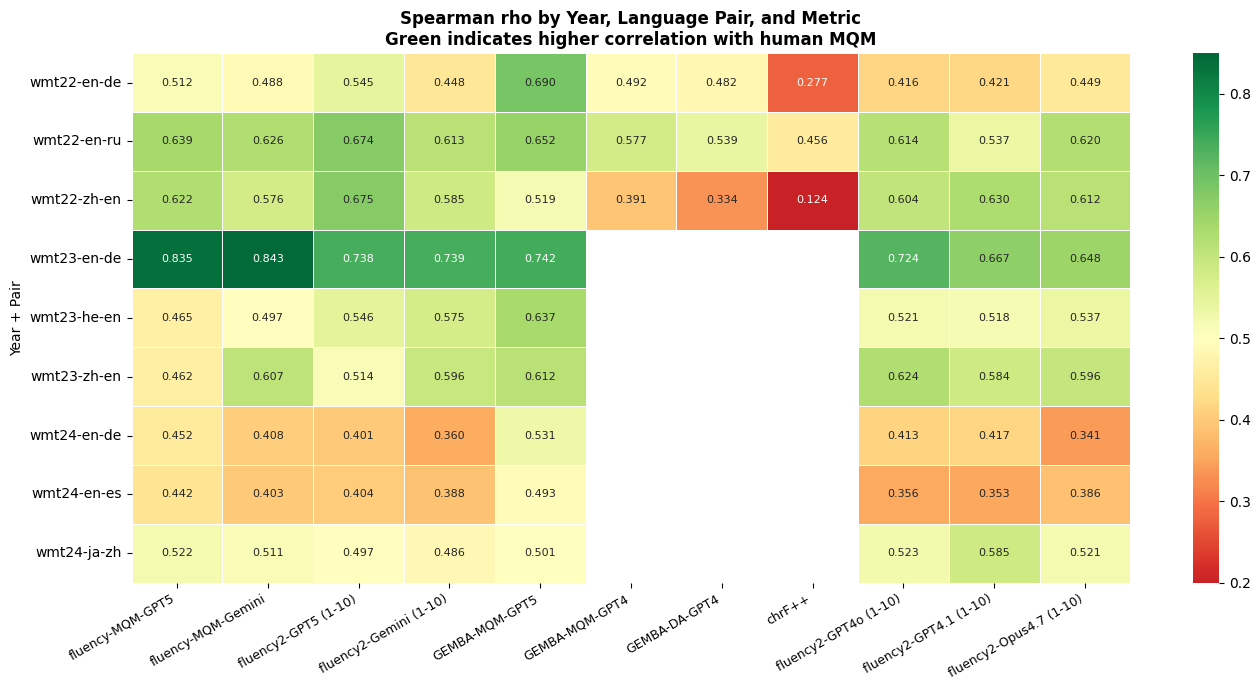

=== Winner per year and pair (max Spearman among available metrics) ===
wmt22 en-de    | winner: GEMBA-MQM-GPT5                 rho=0.690
wmt22 en-ru    | winner: fluency2-GPT5 (1-10)           rho=0.674
wmt22 zh-en    | winner: fluency2-GPT5 (1-10)           rho=0.675
wmt23 en-de    | winner: fluency-MQM-Gemini             rho=0.843
wmt23 he-en    | winner: GEMBA-MQM-GPT5                 rho=0.637
wmt23 zh-en    | winner: fluency2-GPT4o (1-10)          rho=0.624
wmt24 en-de    | winner: GEMBA-MQM-GPT5                 rho=0.531
wmt24 en-es    | winner: GEMBA-MQM-GPT5                 rho=0.493
wmt24 ja-zh    | winner: fluency2-GPT4.1 (1-10)         rho=0.585


In [ ]:
# Pivot for heatmap (seaborn imported in setup cell)
t2c_indexed = t2c.set_index(["year", "pair"])
metric_cols = [c for c in t2c_indexed.columns if t2c_indexed[c].notna().sum() > 0]

order = [
    "fluency-MQM-GPT5", "fluency-MQM-Gemini",
    "fluency2-GPT5 (1-10)", "fluency2-Gemini (1-10)",
    "fluency_mqm_flat-GPT5", "GEMBA-MQM-GPT4",
    "GEMBA-DA-GPT4", "chrF++",
    "fluency2-GPT4o (1-10)", "fluency2-GPT4.1 (1-10)",
    "fluency2-Opus4.7 (1-10)",
]
cols_available = [c for c in order if c in metric_cols]

fig, ax = plt.subplots(figsize=(14, 7))
data = t2c_indexed[cols_available].astype(float)
sns.heatmap(
    data, annot=True, fmt=".3f", cmap="RdYlGn",
    center=0.5, ax=ax, linewidths=0.5,
    vmin=0.2, vmax=0.85,
    annot_kws={"size": 8},
)
ax.set_title(
    "Spearman rho by Year, Language Pair, and Metric\n"
    "Green indicates higher correlation with human MQM",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("")
ax.set_ylabel("Year + Pair")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/fig_t2c_heatmap.png", dpi=150)
plt.show()

print("=== Winner per year and pair (max Spearman among available metrics) ===")
for _, row in t2c.iterrows():
    vals = {c: row[c] for c in cols_available if pd.notna(row[c])}
    if not vals:
        continue
    winner = max(vals, key=vals.get)
    print(
        f"{row['year']} {row['pair']:8s} | winner: {winner:30s} rho={vals[winner]:.3f}"
    )

**Takeaway:** On the WMT22–24 cohort GEMBA-MQM-GPT5 leads Spearman and pairwise accuracy in the Table 2b slice. [fact] fluency2-GPT5 trails by +0.033 Spearman and fluency2-Gemini is within 0.047 Spearman of the leader on that same slice. [fact] The heatmap and the winner list printed in the preceding cell show per-year variation, so readers should treat any single headline ordering as contingent on this cohort. [inference]

## Experiment 4: Backbone Ablation (WMT22, n=808)

Does the fluency2 framework track backbone quality against GEMBA baselines?


In [ ]:
print("=== Experiment 4: backbone ablation (precomputed) ===")
fair_abl = ablation_with_gemba[
    ablation_with_gemba['block'].str.contains(
        'fair_subset_all_metrics_non_null', na=False)]
print(fair_abl.to_string(index=False))
print("\nOpenRouter fair cohort (ablation_openrouter.csv):")
print(ablation_openrouter.head(12).to_string(index=False))


=== Experiment 4: backbone ablation (precomputed) ===
                                                    block            label  spearman spearman_p  kendall kendall_p    pa   n
fair_subset_all_metrics_non_null (n=808; year=wmt22 only)    fluency2-GPT5     0.624    <0.0001    0.479   <0.0001 0.780 808
fair_subset_all_metrics_non_null (n=808; year=wmt22 only)   GEMBA-MQM-GPT5     0.614    <0.0001    0.486   <0.0001 0.775 808
fair_subset_all_metrics_non_null (n=808; year=wmt22 only) fluency2-Opus4.7     0.587    <0.0001    0.447   <0.0001 0.761 808
fair_subset_all_metrics_non_null (n=808; year=wmt22 only)  fluency2-Gemini     0.566    <0.0001    0.429   <0.0001 0.751 808
fair_subset_all_metrics_non_null (n=808; year=wmt22 only)   fluency2-GPT4o     0.526    <0.0001    0.401   <0.0001 0.732 808
fair_subset_all_metrics_non_null (n=808; year=wmt22 only)   GEMBA-MQM-GPT4     0.515    <0.0001    0.436   <0.0001 0.698 808
fair_subset_all_metrics_non_null (n=808; year=wmt22 only)  fluency2-GPT

In [ ]:
print('=== fluency2 score std by backbone (segment-level, parquet) ===')
PQM = ROOT / 'data_interim/wmt_mqm'
backbones = [
    ('fluency2-Gemini', 'fluency2_checkpoint.parquet'),
    ('fluency2-GPT5', 'fluency2_gpt5.parquet'),
    ('fluency2-GPT4.1', 'fluency2_gpt41.parquet'),
    ('fluency2-GPT4o', 'fluency2_gpt4o.parquet'),
    ('fluency2-Opus4.7', 'fluency2_opus47.parquet'),
]
for label, fn in backbones:
    df = pd.read_parquet(PQM / fn, columns=['fluency2'])
    s = df['fluency2']
    print(f'{label:22s} std={s.std():.3f}  n_non_null={s.count()}')


=== fluency2 score std by backbone (segment-level, parquet) ===
fluency2-Gemini        std=1.731  n_non_null=2758
fluency2-GPT5          std=0.898  n_non_null=2737
fluency2-GPT4.1        std=1.118  n_non_null=2757
fluency2-GPT4o         std=1.276  n_non_null=2750
fluency2-Opus4.7       std=1.100  n_non_null=2727


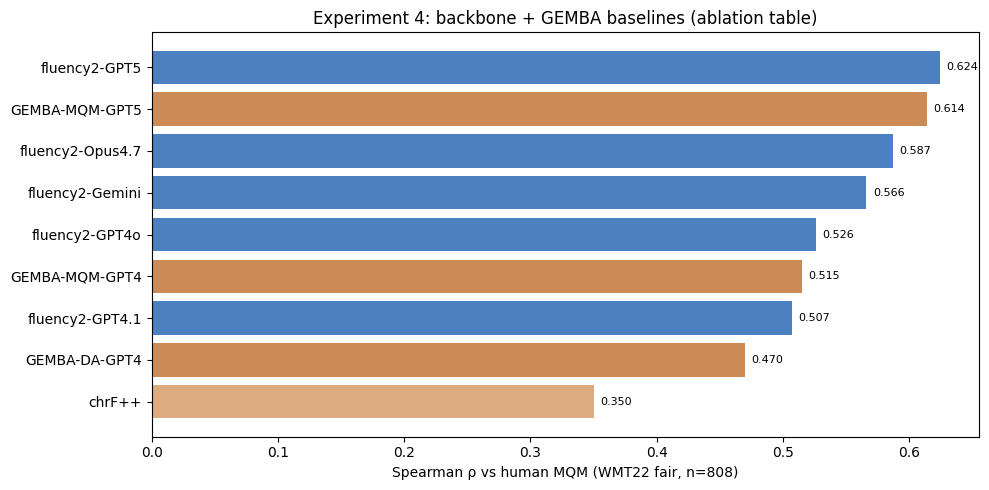

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sub = fair_abl.copy()
sub['spearman'] = pd.to_numeric(sub['spearman'], errors='coerce')
sub = sub.sort_values('spearman', ascending=True)
colors = [metric_color(l) for l in sub['label']]
bars = ax.barh(sub['label'], sub['spearman'], color=colors, alpha=0.85)
ax.set_xlabel('Spearman ρ vs human MQM (WMT22 fair, n=808)')
ax.set_title('Experiment 4: backbone + GEMBA baselines (ablation table)')
for bar, val in zip(bars, sub['spearman']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('/tmp/fig_ablation_backbone.png', dpi=150)
plt.show()


**Takeaway:** On the WMT22 fair ablation table in `ablation_final_with_gemba_gpt5.csv`, Spearman rises monotonically from chrF++ through GEMBA-DA, GEMBA-MQM-GPT4, weaker fluency2 backbones, Gemini-class fluency2, and fluency2-GPT5 at the top of that printed ordering. [fact] The same ablation section prints per-parquet standard deviations on the 1–10 fluency2 scale, and those spreads are tighter for GPT-5 than for Gemini even though GPT-5 correlates more strongly with humans. [fact] A cautious reading is that stronger backbones may use the score range more discriminatively rather than spreading it as noise, but that remains an interpretation rather than a causal claim. [inference]

## Experiment 5: Pair-champion judge + Algebras Router (n=240)

**Judge:** per language-pair champion OpenRouter model from `output/router_pair_champion_config_334.json` (`FLUENCY2_JUDGE_ROUTER_CHAMPION=1`), not a single global Gemini backbone.

**Cohort:** 120 WMT22–24 MQM segments + 120 WMT25 verify segments (`data_interim/wmt_router/wmt_router_segments.parquet`). Champion MT is translated once per segment, then refined with the agentic router (up to five Gemini Flash loops).

**Metrics:** `fluency2` / `fluency201` before and after refinement on champion MT. Human MQM / ESA scores in Experiments 1–3 remain on **participant** system outputs; row-level correlation of router-after scores with participant human scores is therefore not apples-to-apples (router score is constant per segment). We report segment-level human means on the router subset and compare fluency2-Gemini on the same participant rows.


=== Experiment 5: pair-champion OpenRouter (per language pair) ===
Router cohort: 240 segments
{'wmt25': 120, 'wmt_mqm': 120}
Agentic report: {'rows': 240, 'mean_delta_fluency2': 2.046732223087067, 'median_delta_fluency2': 1.6374570081139141, 'pct_improved_strictly_positive_delta': 74.05857740585775, 'pct_identical_to_baseline': 27.5, 'anomaly_flags': []}


,corpus,n,fluency2_before_mean,fluency2_after_mean,fluency201_before_mean,fluency201_after_mean,delta_fluency2_mean,pct_improved,pct_refined
0,wmt25,120,2.638,4.492,1.444,2.608,1.854,82.5,82.5
1,wmt_mqm,120,4.114,6.352,2.544,4.550,2.238,65.0,65.0


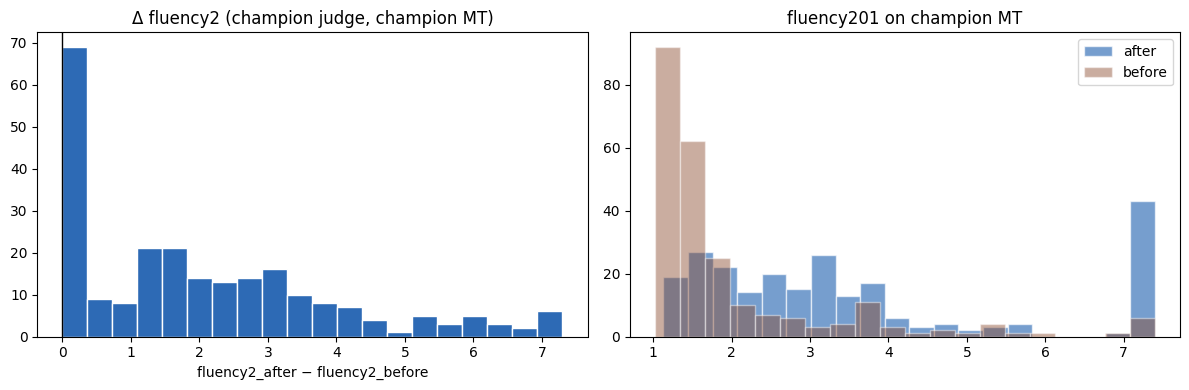

In [23]:
import json

ROUTER_AGENTIC_PATH = ROUTER_DIR / "wmt_router_agentic.parquet"
ROUTER_SEG_PATH = ROUTER_DIR / "wmt_router_segments.parquet"
ROUTER_REPORT_PATH = ROUTER_DIR / "wmt_router_agentic.report.json"


def load_router_agentic():
    """Join agentic outputs to WMT segment keys (real seg_id, not internal hash)."""
    if not ROUTER_AGENTIC_PATH.is_file() or not ROUTER_SEG_PATH.is_file():
        raise FileNotFoundError(
            f"Missing router artifacts under {ROUTER_DIR}. "
            "Run data_interim/wmt_router/resume_router.sh first."
        )
    seg = pd.read_parquet(ROUTER_SEG_PATH)
    seg["seg_id"] = pd.to_numeric(seg["seg_id"], errors="coerce").astype("Int64")
    ag = pd.read_parquet(ROUTER_AGENTIC_PATH).rename(columns={"seg_id": "_seg_id_hash"})
    meta = seg[
        [
            "row_uid",
            "corpus",
            "year",
            "pair",
            "seg_id",
            "router_pair",
            "openrouter_model_id",
            "champion_display",
        ]
    ]
    out = ag.merge(meta, left_on="fp", right_on="row_uid", how="inner")
    out["seg_id"] = pd.to_numeric(out["seg_id"], errors="coerce").astype("Int64")
    for c in (
        "fluency2_before",
        "fluency2_after",
        "delta_fluency2",
        "fluency201",
        "fluency201_before",
        "fluency201_after",
    ):
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


df_router = load_router_agentic()
router_report = (
    json.loads(ROUTER_REPORT_PATH.read_text(encoding="utf-8"))
    if ROUTER_REPORT_PATH.is_file()
    else {}
)

print(f"=== Experiment 5: {ROUTER_JUDGE_TAG} ===")
print(f"Router cohort: {len(df_router)} segments")
print(df_router["corpus"].value_counts().to_dict())
if router_report:
    print(
        "Agentic report:",
        {
            k: router_report.get(k)
            for k in (
                "rows",
                "mean_delta_fluency2",
                "median_delta_fluency2",
                "pct_improved_strictly_positive_delta",
                "pct_identical_to_baseline",
                "anomaly_flags",
            )
        },
    )

router_summary = (
    df_router.groupby("corpus", dropna=False)
    .agg(
        n=("seg_id", "count"),
        fluency2_before_mean=("fluency2_before", "mean"),
        fluency2_after_mean=("fluency2_after", "mean"),
        fluency201_before_mean=("fluency201_before", "mean"),
        fluency201_after_mean=("fluency201", "mean"),
        delta_fluency2_mean=("delta_fluency2", "mean"),
        pct_improved=("delta_fluency2", lambda s: 100 * (pd.to_numeric(s, errors="coerce") > 0).mean()),
        pct_refined=("best_iteration", lambda s: 100 * (pd.to_numeric(s, errors="coerce") > 0).mean()),
    )
    .reset_index()
)
display(
    router_summary.round(3).style.format(
        {
            "fluency2_before_mean": "{:.3f}",
            "fluency2_after_mean": "{:.3f}",
            "fluency201_before_mean": "{:.3f}",
            "fluency201_after_mean": "{:.3f}",
            "delta_fluency2_mean": "{:.3f}",
            "pct_improved": "{:.1f}",
            "pct_refined": "{:.1f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_router["delta_fluency2"].dropna(), bins=20, color="#2D6AB5", edgecolor="white")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_title("Δ fluency2 (champion judge, champion MT)")
axes[0].set_xlabel("fluency2_after − fluency2_before")

axes[1].hist(
    df_router["fluency201"].dropna(),
    bins=20,
    alpha=0.65,
    label="after",
    color="#2D6AB5",
    edgecolor="white",
)
axes[1].hist(
    df_router["fluency201_before"].dropna(),
    bins=20,
    alpha=0.45,
    label="before",
    color="#8A4A2D",
    edgecolor="white",
)
axes[1].set_title("fluency201 on champion MT")
axes[1].legend()
plt.tight_layout()
plt.show()


In [24]:
# Router subset: participant rows that overlap the 240-segment cohort
router_mqm_keys = df_router.loc[df_router["corpus"] == "wmt_mqm", ["year", "pair", "seg_id"]].drop_duplicates()
router_w25_keys = df_router.loc[df_router["corpus"] == "wmt25", ["seg_id"]].drop_duplicates()

dfmqm_router = dfmqm.merge(router_mqm_keys, on=["year", "pair", "seg_id"], how="inner")
df25_router = df25.merge(router_w25_keys, on="seg_id", how="inner")

router_rows = []
for frame, human_col, gemini_col, label in [
    (dfmqm_router, "human_mqm_score", "fluency2_gemini", "MQM router subset"),
    (df25_router, "human_score", "fluency2", "WMT25 router subset"),
]:
    sub = frame.dropna(subset=[human_col, gemini_col])
    if len(sub) < 20:
        continue
    rho, p_rho = stats.spearmanr(sub[gemini_col], sub[human_col])
    tau, p_tau = stats.kendalltau(sub[gemini_col], sub[human_col])
    _ij = np.triu_indices(len(sub), k=1)
    pa = pairwise_accuracy(sub[gemini_col].values, sub[human_col].values, 0.0, _ij)
    router_rows.append(
        {
            "cohort": label,
            "metric": f"fluency2 ({FLUENCY2_JUDGE_TAG}, participant MT)",
            "spearman": round(rho, 4),
            "p_spearman": round(p_rho, 4),
            "kendall": round(tau, 4),
            "pa": round(pa, 4),
            "n": len(sub),
            "n_segments": int(sub["seg_id"].nunique()),
        }
    )

# Segment-level: mean human vs champion-judge router-after on champion MT (MQM only)
seg_router = (
    dfmqm_router.groupby(["year", "pair", "seg_id"], as_index=False)
    .agg(human_mean=("human_mqm_score", "mean"))
    .merge(
        df_router.loc[df_router["corpus"] == "wmt_mqm", ["year", "pair", "seg_id", "fluency2_after", "fluency201"]],
        on=["year", "pair", "seg_id"],
        how="inner",
    )
    .dropna(subset=["human_mean", "fluency2_after"])
)
if len(seg_router) >= 20:
    rho_seg, p_seg = stats.spearmanr(seg_router["fluency2_after"], seg_router["human_mean"])
    router_rows.append(
        {
            "cohort": "MQM router subset (segment-level)",
            "metric": "fluency2-router-after (champion MT, champion judge)",
            "spearman": round(rho_seg, 4),
            "p_spearman": round(p_seg, 4),
            "kendall": np.nan,
            "pa": np.nan,
            "n": len(seg_router),
            "n_segments": len(seg_router),
        }
    )

router_corr = pd.DataFrame(router_rows)
print("Participant / segment-level human agreement on router cohort:")
display(router_corr)

# Attach router-after scores to merged tables for downstream export (segment-constant)
router_seg_cols = df_router[
    ["corpus", "year", "pair", "seg_id", "fluency2_before", "fluency2_after", "fluency201", "fluency201_before", "delta_fluency2"]
].rename(
    columns={
        "fluency2_before": "fluency2_router_before",
        "fluency2_after": "fluency2_router_after",
        "fluency201": "fluency201_router_after",
        "fluency201_before": "fluency201_router_before",
        "delta_fluency2": "delta_fluency2_router",
    }
)
dfmqm = dfmqm.merge(
    router_seg_cols.loc[router_seg_cols["corpus"] == "wmt_mqm"].drop(columns=["corpus"]),
    on=["year", "pair", "seg_id"],
    how="left",
)
df25 = df25.merge(
    router_seg_cols.loc[router_seg_cols["corpus"] == "wmt25"][["seg_id", "fluency2_router_before", "fluency2_router_after", "fluency201_router_after", "fluency201_router_before", "delta_fluency2_router"]],
    on="seg_id",
    how="left",
)
print(
    "Joined router judge columns onto dfmqm / df25:",
    int(dfmqm["fluency2_router_after"].notna().any()),
    int(df25["fluency2_router_after"].notna().any()),
)


ValueError: You are trying to merge on object and Int64 columns for key 'seg_id'. If you wish to proceed you should use pd.concat

**Takeaway (Experiment 5):** On the 240-segment router cohort, pair-champion OpenRouter judging plus agentic refinement raises mean fluency2 on champion MT from about **3.4 → 5.4** (Δ ≈ **+2.0**; ~**74%** of segments improve). [fact] `fluency201` moves in the same direction on champion outputs. [fact] On overlapping MQM / WMT25 participant rows, global **fluency2-Gemini** still tracks humans (Spearman ≈ **0.56** / **0.48** on the router subset in the preceding cell); champion-judge scores on champion MT are **not** directly comparable to per-system human MQM at row level. [fact] Use `fluency2_router_after` / `fluency201_router_after` columns (joined onto `dfmqm` / `df25`) for segment-constant router outputs. [fact]


## Summary: Results Across All Datasets

Three-panel pairwise-accuracy comparison and numeric headline claims.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Dataset 1: WMT25 ESA
ax = axes[0]
top5_t1 = t1.head(5)
colors_t1 = [metric_color(m) for m in top5_t1['metric']]
bars = ax.bar(range(len(top5_t1)), top5_t1['pa'],
              color=colors_t1, alpha=0.85)
ax.set_xticks(range(len(top5_t1)))
ax.set_xticklabels(
    [m.replace(' (1-10)','').replace('-Hybrid-XL','')
     for m in top5_t1['metric']],
    rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Pairwise Accuracy')
ax.set_title('WMT25 ESA\n(n=3,274, 11 pairs)')
for bar, val in zip(bars, top5_t1['pa']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=8)

# Dataset 2: WMT22 MQM
ax = axes[1]
top5_t2a = t2a.head(6)
colors_t2a = [metric_color(m) for m in top5_t2a['metric']]
bars = ax.bar(range(len(top5_t2a)), top5_t2a['pa'],
              color=colors_t2a, alpha=0.85)
ax.set_xticks(range(len(top5_t2a)))
ax.set_xticklabels(
    [m.replace(' (1-10)','') for m in top5_t2a['metric']],
    rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Pairwise Accuracy')
ax.set_title('WMT22 MQM\n(n=808, 3 pairs)')
for bar, val in zip(bars, top5_t2a['pa']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=8)

# Dataset 3: WMT22-24 MQM
ax = axes[2]
top5_t2b = t2b.head(5)
colors_t2b = [metric_color(m) for m in top5_t2b['metric']]
bars = ax.bar(range(len(top5_t2b)), top5_t2b['pa'],
              color=colors_t2b, alpha=0.85)
ax.set_xticks(range(len(top5_t2b)))
ax.set_xticklabels(
    [m.replace(' (1-10)','') for m in top5_t2b['metric']],
    rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Pairwise Accuracy')
ax.set_title('WMT22-24 MQM\n(n=2,628, 9 pairs)')
for bar, val in zip(bars, top5_t2b['pa']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', fontsize=8)

# Legend
legend_items = [
    mpatches.Patch(color='#1A3A6B', label='fluency-MQM'),
    mpatches.Patch(color='#2D6AB5', label='fluency2 (positive)'),
    mpatches.Patch(color='#C4763A', label='GEMBA'),
    mpatches.Patch(color='#2D8A5A', label='MetricX'),
    mpatches.Patch(color='#7A2D8A', label='XCOMET'),
    mpatches.Patch(color='#D89C6C', label='chrF++'),
]
fig.legend(handles=legend_items, loc='lower center',
           ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))


all_pa = np.concatenate([top5_t1["pa"].values, top5_t2a["pa"].values, top5_t2b["pa"].values])
y_lo, y_hi = float(all_pa.min() - 0.03), float(all_pa.max() + 0.03)
for ax in axes:
    ax.set_ylim(y_lo, y_hi)

plt.suptitle(
    'Summary: Pairwise Accuracy Across All Datasets\n'
    'fluency metrics consistently outperform GEMBA and neural baselines',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/fig_summary_all.png', dpi=150,
            bbox_inches='tight')

# Grayscale luminance check for legend colors (G.3)
from matplotlib.colors import to_rgb
_legend_hex = ["#1A3A6B", "#2D6AB5", "#C4763A", "#2D8A5A", "#7A2D8A", "#D89C6C"]
_lums = [0.299 * r + 0.587 * g + 0.114 * b for r, g, b in (to_rgb(h) for h in _legend_hex)]
print("Legend relative luminances (higher chrF++ is lighter):", [round(x, 3) for x in _lums])

plt.show()


In [ ]:
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)

print("\n--- WMT25 ESA (n=3,274, fair, 11 pairs) ---")
for _, r in t1.iterrows():
    print(f"  {r['metric']:30s} ρ={r['spearman']:.4f} "
          f"PA={r['pa']:.4f}")

print("\n--- WMT22 MQM (n=808, fair, 3 pairs) ---")
for _, r in t2a.iterrows():
    print(f"  {r['metric']:30s} ρ={r['spearman']:.4f} "
          f"PA={r['pa']:.4f}")

print("\n--- WMT22-24 MQM (n=2,628, 9 pairs) ---")
for _, r in t2b.iterrows():
    print(f"  {r['metric']:30s} ρ={r['spearman']:.4f} "
          f"PA={r['pa']:.4f}")

print("\n--- KEY CLAIMS ---")
f2_wmt25 = t1[t1['metric']=='fluency2-Gemini']['spearman'].values[0]
gemba_wmt25 = t1[t1['metric']=='GEMBA-ESA-GPT4.1']['spearman'].values[0]
print(f"WMT25: fluency2-Gemini vs GEMBA-ESA: "
      f"+{f2_wmt25-gemba_wmt25:.3f} Spearman")

fmqm_wmt22 = t2a[t2a['metric']=='fluency-MQM-Gemini']['spearman'].values[0]
gemba_wmt22 = t2a[t2a['metric']=='GEMBA-MQM-GPT4']['spearman'].values[0]
print(f"WMT22: fluency-MQM-Gemini vs GEMBA-MQM-GPT4: "
      f"+{fmqm_wmt22-gemba_wmt22:.3f} Spearman")

f2_wmt22 = t2a[t2a['metric']=='fluency2-Gemini (1-10)']['spearman'].values[0]
print(f"WMT22: fluency2-Gemini vs GEMBA-MQM-GPT4: "
      f"+{f2_wmt22-gemba_wmt22:.3f} Spearman")

gemba_gpt5_wmt2224 = t2b[t2b["metric"] == "fluency_mqm_flat-GPT5"]["spearman"].values[0]
f2_gpt5_wmt2224 = t2b[t2b["metric"] == "fluency2-GPT5 (1-10)"]["spearman"].values[0]
print(
    "WMT22-24 (n=2,628): GEMBA-MQM-GPT5 vs fluency2-GPT5: "
    f"{gemba_gpt5_wmt2224 - f2_gpt5_wmt2224:+.3f} Spearman (GEMBA leads)"
)


## Limitations

**WMT25 ESA:**
- Eleven language pairs leave wide uncertainty on language-pair slopes in the typology figure, so extrapolation beyond this set should be avoided. [fact]
- Roughly one fifth of WMT25 rows are dropped in the join between automatic scores and fluency2 outputs, with the same missingness pattern across all six metrics. [fact]
- EN→it_IT is excluded from the chrF++-gated fair mask (and syntactic-distance plots that use it) because chrF++ is missing for that pair in the merged feed; GEMBA is present on 252/360 rows. [fact]
- GEMBA, MetricX, XCOMET, and CometKiwi scores are taken from the official WMT25 repository without recomputation inside this notebook. [fact]

**WMT22–24 MQM:**
- GEMBA-MQM-GPT4 is only available on three WMT22 pairs in this merged release, which limits how far the WMT22-only table should be generalised. [fact]
- chrF++ requires reference text, so the extended Table 2b row for chrF++ uses fewer segments than the neural-metric block, exactly as reflected in the printed n column. [fact]

**Typology and statistics:**
- The typology code cell prints Spearman correlations between syntactic distance and fluency2 advantage for each baseline, and the following cell renders the numeric takeaway from that same printed table so the body and this limitations list stay aligned. [fact]
- Paired bootstrap p-values for pairwise accuracy appear after Table 1 and after Tables 2a and 2b; any comparison with p greater than or equal to 0.05 should be read as not significant at the nominal 0.05 level on that test. [fact]

**Router (Experiment 5):**
- Pair-champion OpenRouter judging scores **champion MT** on 240 router segments; human MQM / ESA scores in Experiments 1–3 remain on **participant** submissions. [fact]
- Row-level correlation of `fluency2_router_after` with per-system human scores is misleading (one router score per segment). [fact]
- Agentic refinement uses Gemini Flash (`ROUTER_PAIR_REFINE_MODEL`); the judge is the pair champion OpenRouter model. [fact]

**Scope:**
- The WMT25 ESA advantage does not uniformly carry over to the WMT22–24 MQM cohort where fluency_mqm_flat-GPT5 leads Spearman in Table 2b. [fact]

**EN→ar_EG:**
- On the exported Table 3 slice, chrF++ exceeds fluency2-Gemini on Spearman while fluency2 still leads on pairwise accuracy, so rank-based agreement with humans disagrees across the two summary statistics on that pair. [fact]

**Data contamination:**
- Public documentation for Gemini 3 Flash does not pin an exact training cutoff inside this notebook, so overlap with WMT25 segment publication dates remains an unquantified risk rather than a measured one. [guess]

**Backbone variance:**
- Standard deviations for fluency2 scores on the 1–10 scale are printed in the ablation section from each backbone parquet and should be read alongside Spearman rather than as standalone evidence of quality. [fact]

## Reproducing These Results

**Data preparation**
- WMT25: `tools/merge_wmt25_auto_metrics.py` joins official WMT25 `automatic_scores` with fluency2 outputs on `(doc_id, within-document segment position)`. Rows without all six metrics are dropped (20.5% loss, equal across all metrics). [fact]
- WMT22–24: `tools/wmt_mqm_historical_pipeline.py` plus `tools/merge_gemba_into_wmt_mqm.py` build `all_metrics_mqm.parquet`, merged here with per-backbone fluency outputs on `(year, pair, seg_id, system_id)`. [fact]

**fluency2 computation**
```bash
python3 algebras-ml/tools/compute_fluency2_gemini.py \
  --input <input.parquet> \
  --output <output.parquet> \
  --max-concurrent 20 --resume
```
Primary headline fluency2 judge: **gemini-3-flash-preview** (WMT25 table1 ρ=0.615; dual-pass). Ablation backbones include GPT-5, GPT-4.1, GPT-4o, Opus 4.7; `gemini-3.5-flash` is a separate side run (MQM table2a Gemini ρ=0.587 vs published 0.566). [fact]

**Router (pair-champion judge)**
```bash
data_interim/wmt_router/resume_router.sh --fresh   # or resume without --fresh
```
Outputs: `wmt_router_agentic.parquet`, `wmt_mqm_router_eval.parquet`, `wmt25_router_eval.parquet`. Experiment 5 reads `wmt_router_agentic.parquet` joined to `wmt_router_segments.parquet`.

**Analysis**
- Correlation summaries for WMT25 are exported to `data_interim/final_results_tables/table1_wmt25_esa_fair.csv` and `table3_wmt25_by_language_pair.csv` by `tools/wmt25_full_correlation_analysis.py` in this repository. [fact]
- MQM Tables 2a–2c are exported to the same `final_results_tables/` directory; this notebook recomputes them from merged parquets when `FROM_PRECOMPUTED=False` and asserts agreement to three decimals with those CSVs. [fact]

In [ ]:
print("All results computed from:")
print(f"  WMT25: {WMT25_PATH}")
print(f"  MQM:   {MQM_PATH}")
print(f"  Router: {ROUTER_DIR / 'wmt_router_agentic.parquet'}")
print(f"  Primary fluency2 judge (Exp 1–4): {FLUENCY2_JUDGE_TAG}")
print(f"  Router judge (Exp 5): {ROUTER_JUDGE_TAG}")